In [ ]:
# CUSTOMER CHURN PREDICTION SYSTEM
# Which customers are likely to stop purchasing

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [1]:
import pandas as pd
df = pd.read_csv(r"D:\customer-intelligence-dashboard\data\cleaned_ecommerce_data.csv")

In [2]:
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               350 non-null    int64  
 1   gender                    350 non-null    object 
 2   age                       350 non-null    int64  
 3   city                      350 non-null    object 
 4   membership_type           350 non-null    object 
 5   total_spend               350 non-null    float64
 6   items_purchased           350 non-null    int64  
 7   average_rating            350 non-null    float64
 8   discount_applied          350 non-null    bool   
 9   days_since_last_purchase  350 non-null    int64  
 10  satisfaction_level        350 non-null    object 
 11  customer_value            350 non-null    float64
 12  customer_segment          350 non-null    object 
 13  recency_score             350 non-null    object 
dtypes: bool(1)

(350, 14)

In [3]:
def churn(x):
    if x > 50:
        return 1
    else:
        return 0
df['churn'] = df['days_since_last_purchase'].apply(churn)

In [4]:
df['churn'].value_counts()

churn
0    326
1     24
Name: count, dtype: int64

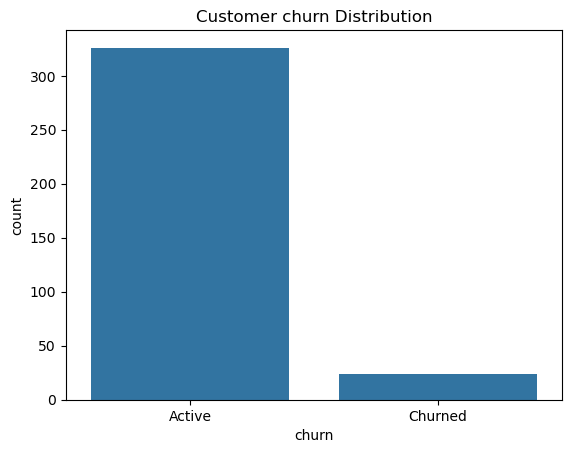

In [5]:
# Visualize churn distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='churn',data=df)
plt.xticks([0,1],['Active','Churned'])
plt.title("Customer churn Distribution")
plt.show()

In [6]:
df.head()

,customer_id,gender,age,city,membership_type,total_spend,items_purchased,average_rating,discount_applied,days_since_last_purchase,satisfaction_level,customer_value,customer_segment,recency_score,churn
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,80.014286,High,Medium,0
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,70.954545,Medium,High,0
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,56.750000,Medium,Medium,0
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,77.910526,High,High,0
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,55.415385,Medium,Low,1


In [7]:
X = pd.DataFrame(df.iloc[:,2:10])

X = X.drop('city',axis=1)
X.head()

,age,membership_type,total_spend,items_purchased,average_rating,discount_applied,days_since_last_purchase
0,29,Gold,1120.20,14,4.6,True,25
1,34,Silver,780.50,11,4.1,False,18
2,43,Bronze,510.75,9,3.4,True,42
3,30,Gold,1480.30,19,4.7,False,12
4,27,Silver,720.40,13,4.0,True,55


In [8]:
Y = pd.DataFrame(df.iloc[:,14])
Y.head()

,churn
0,0
1,0
2,0
3,0
4,1


In [9]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,age,total_spend,items_purchased,average_rating,discount_applied,days_since_last_purchase,membership_type_Gold,membership_type_Silver
0,29,1120.20,14,4.6,True,25,True,False
1,34,780.50,11,4.1,False,18,False,True
2,43,510.75,9,3.4,True,42,False,False
3,30,1480.30,19,4.7,False,12,True,False
4,27,720.40,13,4.0,True,55,False,True


In [10]:
X.shape
#Y.shape

(350, 8)

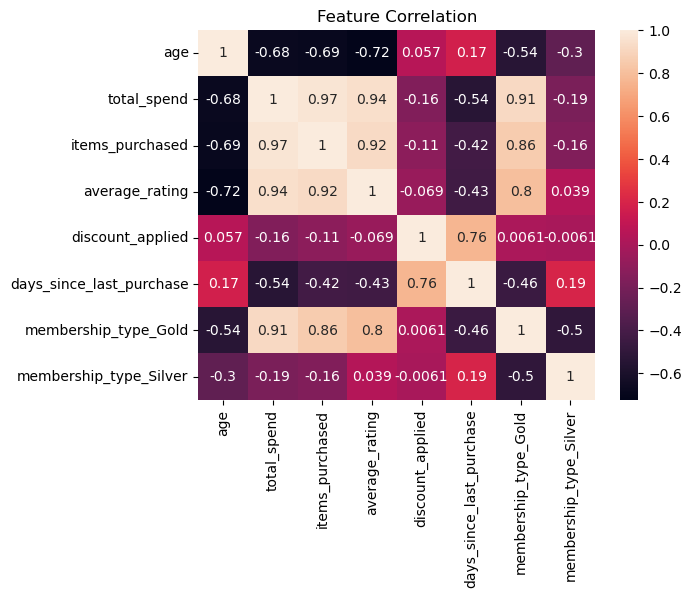

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(X.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [13]:
X_train.shape
X_test.shape

(70, 8)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [15]:
Y_pred = model.predict(X_test)
print(X_test[:5],Y_pred[:5])

     age  total_spend  items_purchased  average_rating  discount_applied  \
157   35       810.90               12             4.3             False   
341   31      1140.60               15             4.5              True   
315   27       710.40               13             4.1              True   
234   33       830.75               13             4.2             False   
155   37       430.80                7             3.4             False   

     days_since_last_purchase  membership_type_Gold  membership_type_Silver  
157                        13                 False                    True  
341                        36                  True                   False  
315                        61                 False                    True  
234                        14                 False                    True  
155                        23                 False                   False   [0 0 1 0 0]


In [16]:
print(Y_test[:5])

     churn
157      0
341      0
315      1
234      0
155      0


In [17]:
# Model Evaluation
# We evaluate:Accuracy ,Precision ,Recall ,Confusion Matrix
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test,Y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [18]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00         4

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [19]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,Y_pred)
print(cm)

[[66  0]
 [ 0  4]]


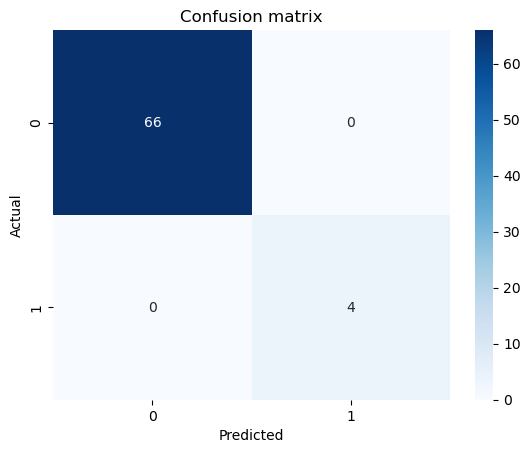

In [20]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [21]:
# feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
    })
importance.sort_values(by='Coefficient', ascending =False)

,Feature,Coefficient
5,days_since_last_purchase,1.280018
2,items_purchased,0.243464
7,membership_type_Silver,0.027928
3,average_rating,0.006717
6,membership_type_Gold,-0.000105
4,discount_applied,-0.019305
1,total_spend,-0.061181
0,age,-0.920897


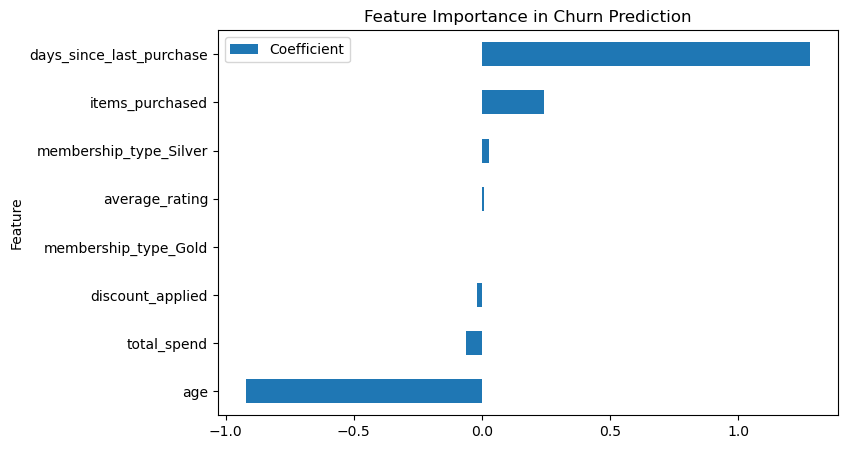

In [22]:
importance = importance.sort_values(by='Coefficient',ascending=True)
importance.plot(
    x='Feature',
    y='Coefficient',
    kind='barh',
    figsize=(8,5)
)
plt.title("Feature Importance in Churn Prediction")
plt.show()

In [25]:
# Predicted probabilities for positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)
auc_score = roc_auc_score(Y_test, y_pred_proba)


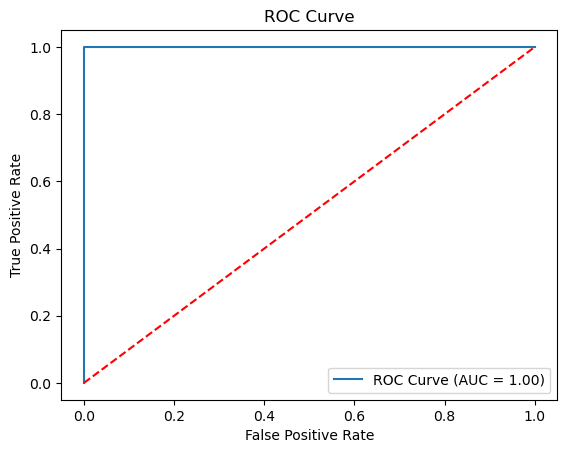

In [26]:
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.plot([0,1], [0,1], linestyle="--", color="red")  # Random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
